In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('gia_nha.csv', index_col='ID_nha')

features = ['Dien_tich', 'So_phong']
X = data[features]
y = data['Gia_ty']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, test_size=0.25, random_state=42)

In [3]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=3, shuffle=True, random_state=42)

degrees = [1, 2, 3, 4]
results = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    mean_mse = (-scores).mean()
    results.append([degree, mean_mse])

results_df = pd.DataFrame(results, columns=['Degree', 'Mean CV MSE'])
results_df

,Degree,Mean CV MSE
0,1,0.125198
1,2,1.068335
2,3,1.683980
3,4,2.118844


In [4]:
best_degree = results_df.loc[results_df['Mean CV MSE'].idxmin(), 'Degree']
print("Best Degree tìm được bằng K-Fold:", int(best_degree))

final_model = make_pipeline(
    PolynomialFeatures(degree=int(best_degree), include_bias=False),
    LinearRegression()
)
final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
test_mse = np.mean((y_test - y_test_pred) ** 2)

print("Mean CV MSE tốt nhất:", results_df['Mean CV MSE'].min())
print("Test MSE của mô hình tối ưu:", test_mse)

Best Degree tìm được bằng K-Fold: 1
Mean CV MSE tốt nhất: 0.12519788615940144
Test MSE của mô hình tối ưu: 0.12241299729814391


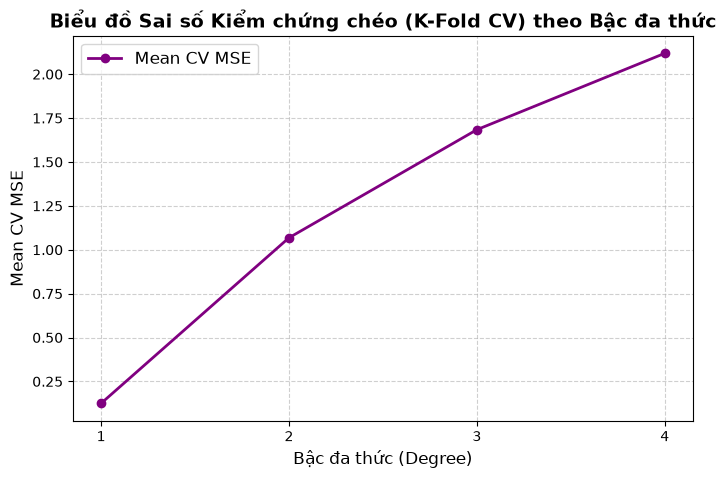

In [5]:
plt.figure(figsize=(8, 5))

# Vẽ đường Mean CV MSE
plt.plot(results_df['Degree'], results_df['Mean CV MSE'], marker='o', color='purple', linewidth=2, label='Mean CV MSE')

# Trang trí biểu đồ
plt.xlabel('Bậc đa thức (Degree)', fontsize=12)
plt.ylabel('Mean CV MSE', fontsize=12)
plt.title('Biểu đồ Sai số Kiểm chứng chéo (K-Fold CV) theo Bậc đa thức', fontsize=14, fontweight='bold')
plt.xticks(results_df['Degree'])
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()